### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
from scipy.stats import mode
from imblearn.over_sampling import RandomOverSampler

### Step 2: Load Dataset

In [5]:
df = pd.read_csv('./data/improved_disease_dataset.csv')

In [6]:
df.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [7]:
df.shape

(2000, 11)

### Step 3: Exploaring Data

In [8]:
df.describe()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,0.328000,0.413000,0.378500,0.526000,0.365500,0.450500,0.387000,0.55500,0.456000,0.449000
std,0.469602,0.492496,0.485134,0.499448,0.481691,0.497668,0.487185,0.49709,0.498185,0.497517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   fever        2000 non-null   int64 
 1   headache     2000 non-null   int64 
 2   nausea       2000 non-null   int64 
 3   vomiting     2000 non-null   int64 
 4   fatigue      2000 non-null   int64 
 5   joint_pain   2000 non-null   int64 
 6   skin_rash    2000 non-null   int64 
 7   cough        2000 non-null   int64 
 8   weight_loss  2000 non-null   int64 
 9   yellow_eyes  2000 non-null   int64 
 10  disease      2000 non-null   object
dtypes: int64(10), object(1)
memory usage: 172.0+ KB


In [10]:
df.isna().sum()

fever          0
headache       0
nausea         0
vomiting       0
fatigue        0
joint_pain     0
skin_rash      0
cough          0
weight_loss    0
yellow_eyes    0
disease        0
dtype: int64

In [11]:
df.isnull().sum()

fever          0
headache       0
nausea         0
vomiting       0
fatigue        0
joint_pain     0
skin_rash      0
cough          0
weight_loss    0
yellow_eyes    0
disease        0
dtype: int64

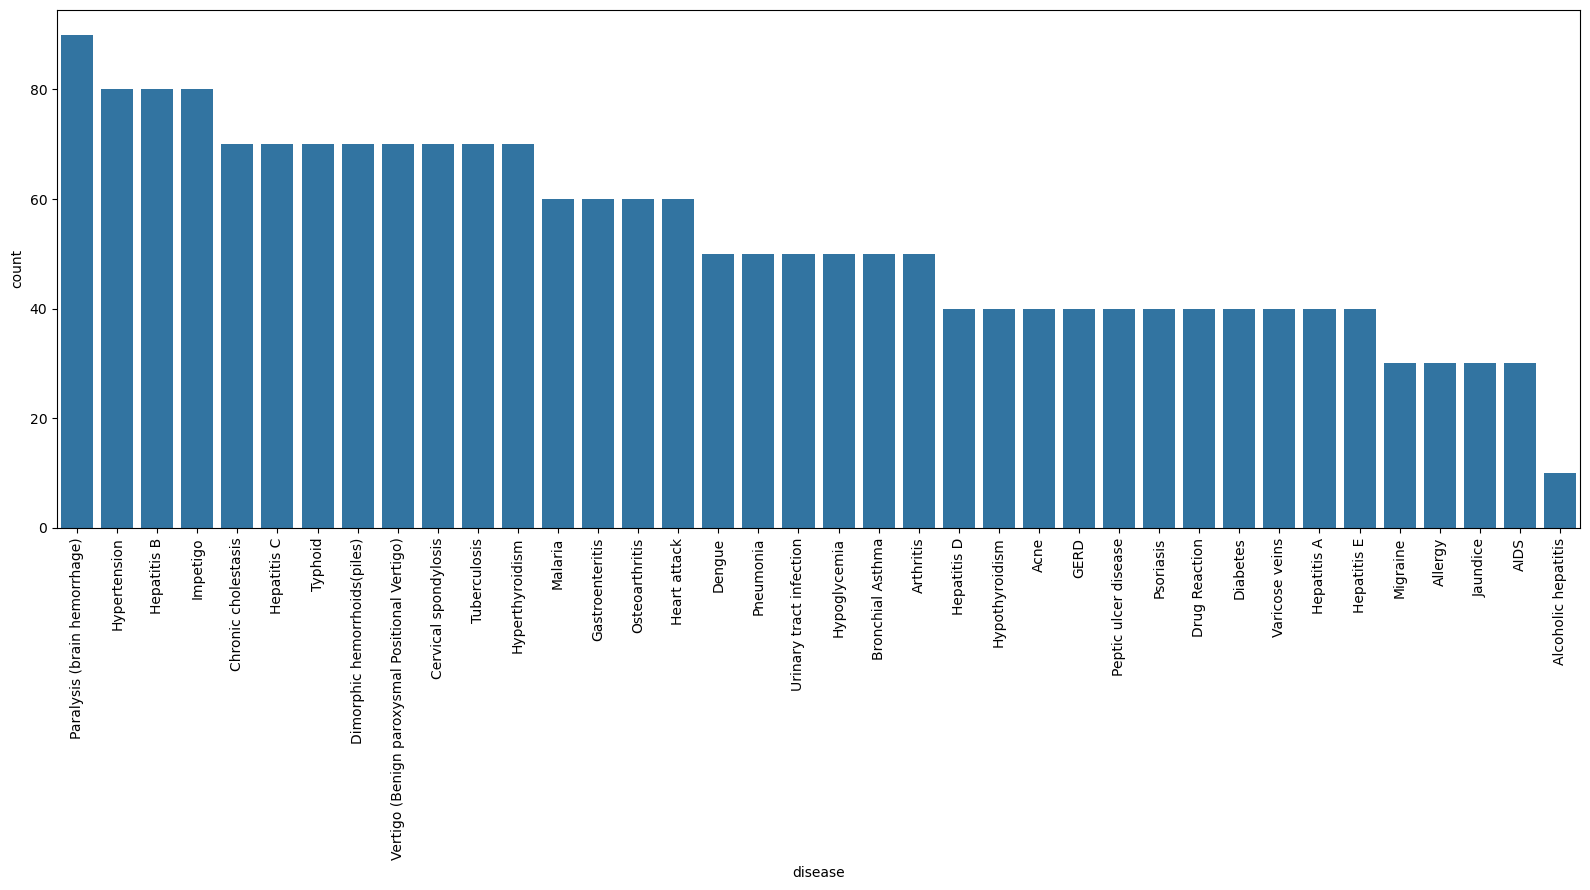

In [26]:
plt.figure(figsize=(16, 9))
sns.countplot(x=df['disease'], orient='v')
plt.xticks(rotation=90)
plt.tight_layout()

### Step 4: Feature Engineering

In [27]:
le = LabelEncoder()

In [28]:
df['disease'] = le.fit_transform(df['disease'])

### Setp 5: Preparing Data

In [31]:
features = df.drop('disease',axis=1)
target = df['disease']

In [30]:
ros = RandomOverSampler(random_state=42)

In [35]:
features, target = ros.fit_resample(features, target)

### Step 6: Evaluate Model

In [57]:
models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    SVC(),
    GaussianNB()
]

In [58]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [59]:
for model in models:
    scores = cross_val_score(
        model,
        features,
        target,
        cv=stratified_kfold,
        scoring='accuracy',
        n_jobs=-1,
        error_score='raise'
    )

    print(f'Model: {model.__class__.__name__}')
    print(f'Scores: {scores}')
    print(f'Mean Accuracy: {scores.mean():.3f}')
    print('-' * 30)

Model: DecisionTreeClassifier
Scores: [0.5497076  0.54385965 0.53508772 0.53654971 0.52777778]
Mean Accuracy: 0.539
------------------------------
Model: RandomForestClassifier
Scores: [0.55994152 0.55701754 0.54239766 0.53508772 0.53070175]
Mean Accuracy: 0.545
------------------------------
Model: SVC
Scores: [0.51315789 0.51169591 0.49707602 0.48245614 0.49561404]
Mean Accuracy: 0.500
------------------------------
Model: GaussianNB
Scores: [0.36403509 0.17982456 0.3625731  0.33479532 0.37134503]
Mean Accuracy: 0.323
------------------------------


### Step 7: Confusion Matrices

SVM

In [49]:
svm_model = SVC()

In [50]:
svm_model.fit(features, target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
svm_pred = svm_model.predict(features)

In [52]:
cf_matrix_svm = confusion_matrix(target, svm_pred)

In [56]:
print(f"SVM Accuracy: {accuracy_score(target, svm_pred) * 100:.2f}%")

SVM Accuracy: 60.53%


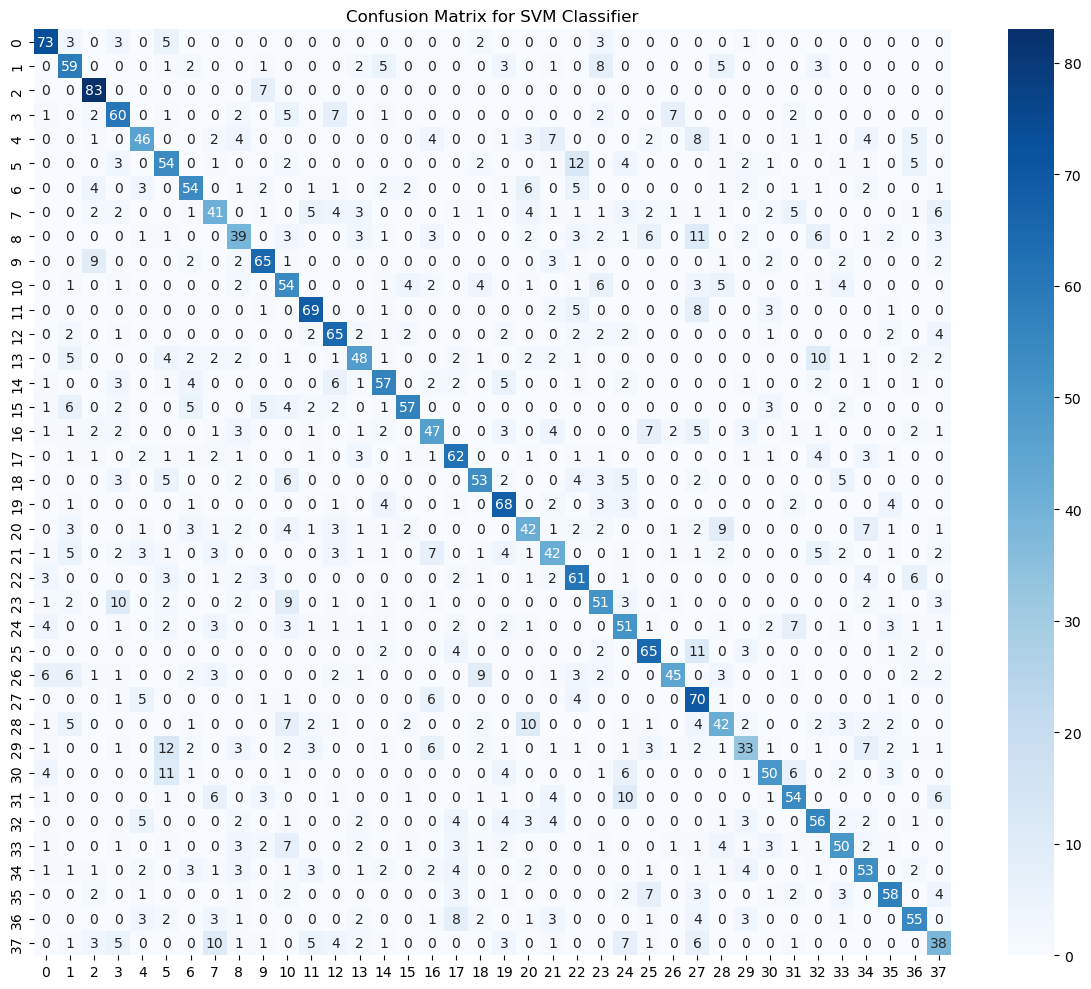

In [55]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cf_matrix_svm,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for SVM Classifier')
plt.tight_layout()

Random Forest Classifier

In [60]:
rf_model = RandomForestClassifier(random_state=42)

In [61]:
rf_model.fit(features, target)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
rf_pred = rf_model.predict(features)

In [63]:
cf_matrix_rf = confusion_matrix(target, rf_pred)

In [72]:
print(f"Random Forest Accuracy: {accuracy_score(target, rf_pred) * 100:.2f}%")

Random Forest Accuracy: 68.98%


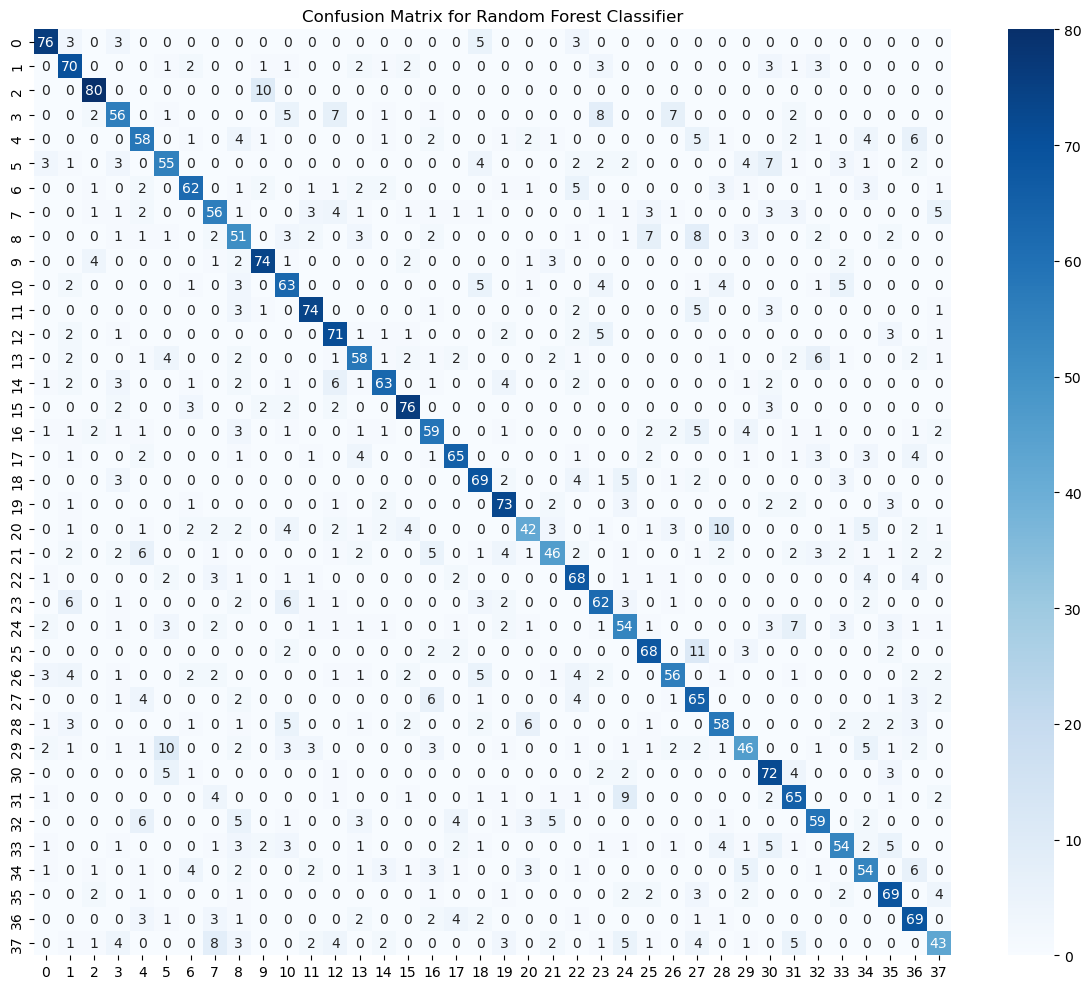

In [66]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cf_matrix_rf,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.tight_layout()

Decision Tree

In [67]:
dt_model = DecisionTreeClassifier(random_state=42)

In [68]:
dt_model.fit(features, target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [69]:
dt_pred = dt_model.predict(features)

In [70]:
cf_matrix_dt = confusion_matrix(target, dt_pred)

In [71]:
print(f"Decision Tree Accuracy: {accuracy_score(target, dt_pred) * 100:.2f}%")

Decision Tree Accuracy: 68.98%


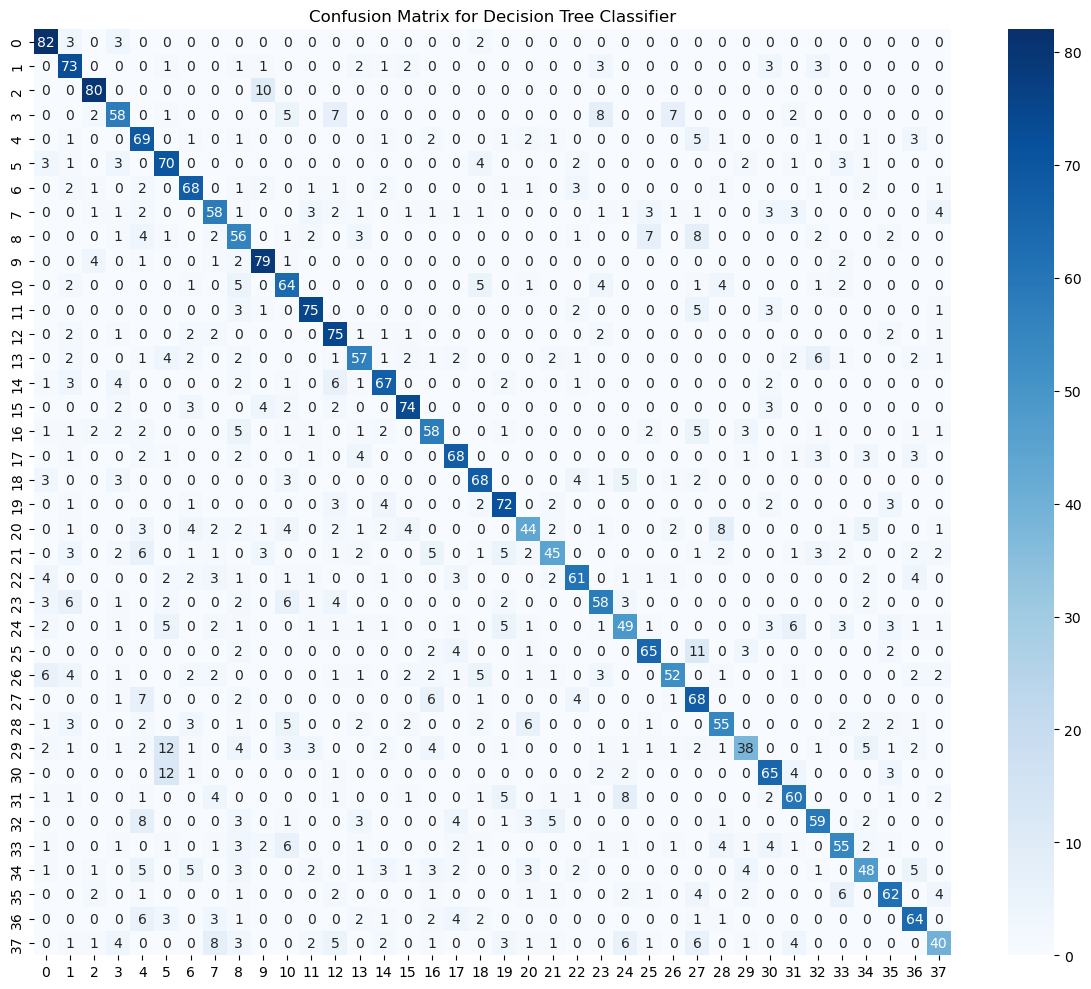

In [73]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cf_matrix_dt,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.tight_layout()

Gaussian Naive Bayes

In [74]:
nb_model = GaussianNB()

In [75]:
nb_model.fit(features, target)

,priors,None
,var_smoothing,1e-09


In [76]:
nb_pred = nb_model.predict(features)

In [77]:
cf_matrix_nb = confusion_matrix(target, nb_pred)

In [78]:
print(f"Gaussian Naive Bayes Accuracy: {accuracy_score(target, nb_pred) * 100:.2f}%")

Gaussian Naive Bayes Accuracy: 37.98%


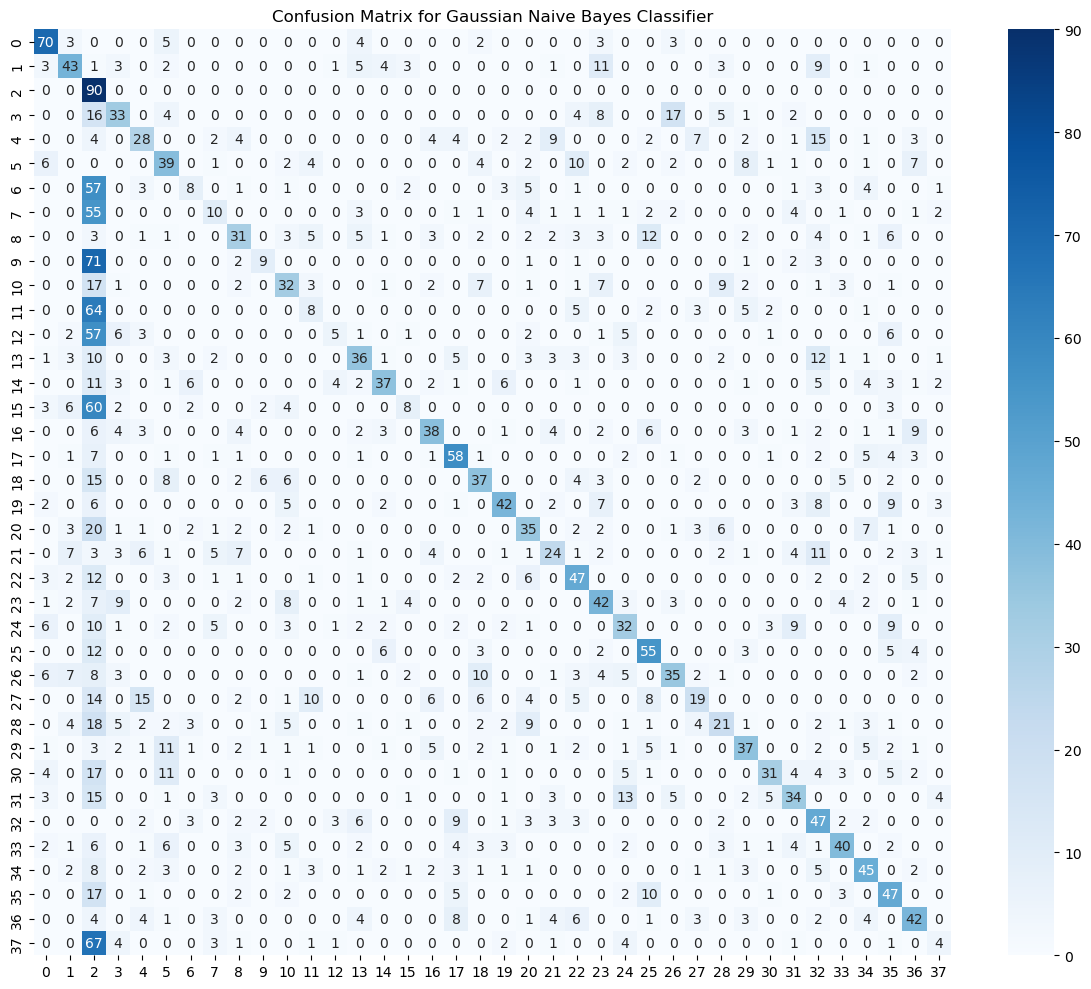

In [79]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cf_matrix_nb,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for Gaussian Naive Bayes Classifier')
plt.tight_layout()

In [102]:
final_preds = [mode([i, j, k, l]).mode for i, j, k, l in zip(svm_pred, nb_pred, rf_pred, dt_pred)]

In [103]:
cf_matrix_combined = confusion_matrix(target, final_preds)

In [104]:
print(f"Combined Model Accuracy: {accuracy_score(target, final_preds) * 100:.2f}%")

Combined Model Accuracy: 66.05%


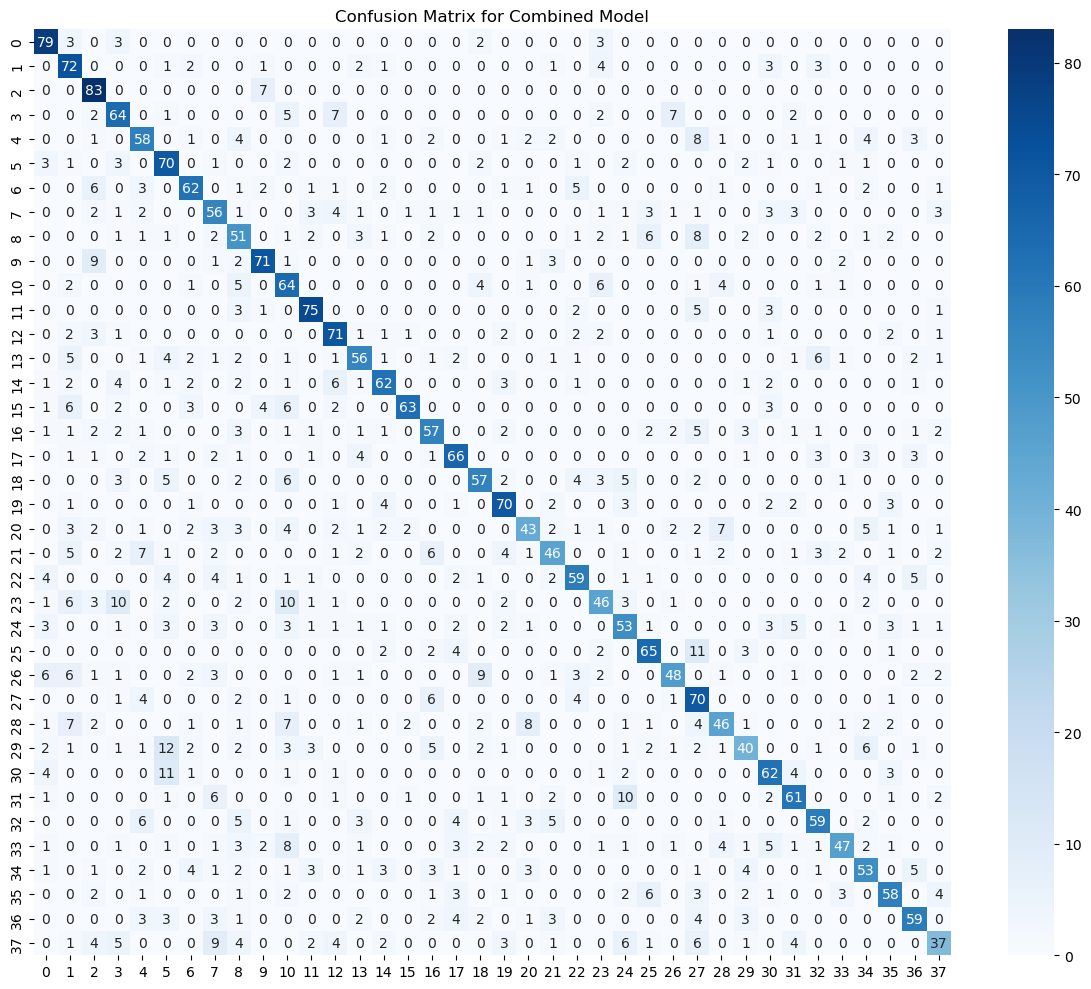

In [105]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cf_matrix_combined,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix for Combined Model')
plt.tight_layout()

### Step 8: Creating Prediction Function

In [111]:
symptoms = features.columns.values
symptom_index = {symptom: idx for idx, symptom in enumerate(symptoms)}

In [128]:
def predict_disease(input_symptoms):
    input_symptoms = input_symptoms.split(",")
    input_data = [0] * len(symptom_index)
    
    for symptom in input_symptoms:
        if symptom in symptom_index:
            input_data[symptom_index[symptom]] = 1

    input_df = pd.DataFrame([input_data], columns=symptoms)

    rf_pred = rf_model.predict(input_df)[0]
    nb_pred = nb_model.predict(input_df)[0]
    svm_pred = svm_model.predict(input_df)[0]

    final_pred = mode([rf_pred, nb_pred, svm_pred]).mode
    
    return {
        "Random Forest Prediction": le.classes_[rf_pred],
        "Naive Bayes Prediction": le.classes_[nb_pred],
        "SVM Prediction": le.classes_[svm_pred],
        "Final Prediction": le.classes_[final_pred]
    }

In [129]:
predict_disease('skin_rash,fever,headache')

{'Random Forest Prediction': 'Peptic ulcer disease',
 'Naive Bayes Prediction': 'Impetigo',
 'SVM Prediction': 'Peptic ulcer disease',
 'Final Prediction': 'Peptic ulcer disease'}